# EXPRESSION DATA

In [73]:
import pandas as pd
from functools import reduce

# =========================================== #
# FILTER FOR 1:1 ORTHOLOGS AND RENAME COLUMNS #
# =========================================== #

kinases_orthologs = pd.read_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/human_mouse_orthoKinases.txt", delimiter="\t")

# Filter out "ortholog_one2many"
kinases_1to1orthologs = kinases_orthologs[kinases_orthologs["Mouse homology type"] == "ortholog_one2one"].copy()

# Change column names: Gene stable ID version		Mouse homology type	Mouse gene name	Gene name
kinases_1to1orthologs.rename(columns={"Mouse homology type": "homology",
                                      "Mouse gene stable ID": "gene_id_mouse",
                                      "Mouse gene name": "gene_name_mouse",
                                      "Gene name": "gene_name_human",
                                      "Gene stable ID version": "gene_id_human"
                                      }, inplace=True)

kinases_1to1orthologs = kinases_1to1orthologs[["gene_id_human", "gene_name_human", "gene_id_mouse", "gene_name_mouse", "homology"]].copy()

# delete version of gene_id_human
kinases_1to1orthologs["gene_id_human"] = kinases_1to1orthologs["gene_id_human"].str.split(".").str[0]

# capitalize gene_name_mouse
kinases_1to1orthologs["gene_name_mouse"] = kinases_1to1orthologs["gene_name_mouse"].str.upper()

# Save it
kinases_1to1orthologs.to_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/human_mouse_orthoKinases_one2one.txt", sep="\t", index=False)


# ================================================================================= #
# JOIN INFORMATION OF DIFFERENT TISSUES OF EACH SPECIE AND EXTRACT TPMs AND GENE ID #
# ================================================================================= #

# Data
datasets_mouse = {
    "ENCFF890GTZ": "adrenal_gland",
    "ENCFF707MBR": "brain",
    "ENCFF546IKJ": "muscle",
    "ENCFF519HZD": "heart",
    "ENCFF161ZNN": "liver"
}

datasets_human = {
    "ENCFF783MER": "adrenal_gland",
    "ENCFF725USM": "brain",
    "ENCFF296APA": "muscle",
    "ENCFF717ZEJ": "heart",
    "ENCFF658ESI": "liver",
}

def process_datasets(datasets_dict, species, kinases_1to1orthologs):

    # Empty dictionary to store processed datasets
    processed_datasets = {}
    
    # Access to every entry of the dictionary
    for file_name, tissue in datasets_dict.items():

        # Retrieve only gene name and expression column (TPM)
        file_path = f"C:/Users/vicfo/Desktop/TFM/project/Data/data_gathering/new/{file_name}.tsv"
        df = pd.read_csv(file_path, delimiter="\t")
        df = df[["gene_id", "TPM"]]
        df.rename(columns={"TPM": f"{tissue}_tpm_{species}"}, inplace=True)

        # Delete gene version
        df[f"gene_id_{species}"] = df["gene_id"].str.split(".").str[0]
        df.drop(columns=["gene_id"], inplace=True)

        print("Processing tissue:", tissue, "for species:", species)

        # Keep only entries that are in the kinase orthologs list
        df_filtered = pd.merge(df,kinases_1to1orthologs[[f"gene_id_{species}", f"gene_name_{species}"]],on=f"gene_id_{species}",how="inner",)

        # Store in "processed_datasets" dictionary
        processed_datasets[tissue] = df_filtered

    return processed_datasets

processed_datasets_mouse = process_datasets(datasets_mouse, "mouse", kinases_1to1orthologs)
processed_datasets_human = process_datasets(datasets_human, "human", kinases_1to1orthologs)


# ===================================== #
# JOIN DATASETS - MERGE HUMAN AND MOUSE #
# ===================================== #

def join_datasets(dictionary, species):

    # Merge different tissue expression dataframes into a single dataframe
    merged_df = reduce(
    lambda left, right: pd.merge(
        left, right, on=[f"gene_id_{species}", f"gene_name_{species}"], how="outer"
    ),
    list(dictionary.values()),
    )

    # Sort column names "gene_id_{species}", "gene_name_{species}" first, then the rest
    cols = merged_df.columns.tolist()
    cols.insert(0, cols.pop(cols.index(f"gene_id_{species}")))
    cols.insert(1, cols.pop(cols.index(f"gene_name_{species}")))
    merged_df = merged_df[cols]

    return merged_df

table_mouse = join_datasets(processed_datasets_mouse, "mouse")
table_human = join_datasets(processed_datasets_human, "human")

# Merge the result with mouse expression to create the final paired dataset
table_human = table_human.rename(columns={"gene_name_human": "gene_name"})
table_mouse = table_mouse.rename(columns={"gene_name_mouse": "gene_name"})

final_df = pd.merge(table_human, table_mouse, on="gene_name", how="inner")

# Sort column names "gene_id_human", "gene_name", "gene_id_mouse" first, then the rest
cols = final_df.columns.tolist()
cols.insert(0, cols.pop(cols.index("gene_id_human")))
cols.insert(1, cols.pop(cols.index("gene_id_mouse")))
cols.insert(2, cols.pop(cols.index("gene_name")))
final_df = final_df[cols]

final_df.to_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/merged_expression_humanmouse_kinases_1to1orthologs.txt", sep="\t", index=False)

Processing tissue: adrenal_gland for species: mouse
Processing tissue: brain for species: mouse
Processing tissue: muscle for species: mouse
Processing tissue: heart for species: mouse
Processing tissue: liver for species: mouse
Processing tissue: adrenal_gland for species: human
Processing tissue: brain for species: human
Processing tissue: muscle for species: human
Processing tissue: heart for species: human
Processing tissue: liver for species: human


### For the moment, keep only genes we already had in the previous analysis, so we just update their expression values. 

In [41]:
import pandas as pd
original_genes = pd.read_csv("C:/Users/vicfo/Desktop/TFM/project/data/merged_kinases_tpm_humanandmouse.tsv", sep="\t")
new_genes = pd.read_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/merged_expression_humanmouse_kinases_1to1orthologs.txt", sep="\t")
new_genes_original = pd.merge(new_genes,original_genes[["gene_name", "gene_id_human", "gene_id_mouse"]],on=["gene_name", "gene_id_human", "gene_id_mouse"],how="inner")
new_genes_original.to_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/new_expression_data.txt", sep="\t", index=False)

### Filter new genes

In [ ]:
for specie in ["human", "mouse"]:

    # If the expression in all the tissues of an specie is 0, filter out the gene.
    new_genes = new_genes[(new_genes[[f"adrenal_gland_tpm_{specie}",
                                       f"muscle_tpm_{specie}",
                                       f"liver_tpm_{specie}",
                                       f"brain_tpm_{specie}",
                                       f"heart_tpm_{specie}"]] > 0).all(axis=1)]
    # If the expression in any of the tissues of an specie is >150, filter out the gene.
    new_genes = new_genes[(new_genes[[f"adrenal_gland_tpm_{specie}",
                                       f"muscle_tpm_{specie}",
                                       f"liver_tpm_{specie}",
                                       f"brain_tpm_{specie}",
                                       f"heart_tpm_{specie}"]] <= 150).all(axis=1)]

new_genes

,gene_id_human,gene_id_mouse,gene_name,adrenal_gland_tpm_human,brain_tpm_human,muscle_tpm_human,heart_tpm_human,liver_tpm_human,adrenal_gland_tpm_mouse,brain_tpm_mouse,muscle_tpm_mouse,heart_tpm_mouse,liver_tpm_mouse
0,ENSG00000000457,ENSMUSG00000026584,SCYL3,2.30,1.84,2.97,2.89,5.13,5.17,11.33,1.71,1.71,1.04
1,ENSG00000000938,ENSMUSG00000028874,FGR,2.73,1.17,1.19,0.71,0.54,0.18,0.08,0.01,0.23,0.14
2,ENSG00000004455,ENSMUSG00000028792,AK2,24.70,17.11,47.65,54.24,69.91,51.35,10.77,11.05,31.55,25.21
3,ENSG00000004660,ENSMUSG00000020785,CAMKK1,2.23,28.78,0.14,1.29,0.18,1.40,49.05,0.11,0.37,0.03
6,ENSG00000006062,ENSMUSG00000020941,MAP3K14,1.79,1.95,2.74,5.58,23.26,3.27,1.44,1.81,0.99,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,ENSG00000269335,ENSMUSG00000004221,IKBKG,5.06,7.56,27.41,7.30,7.29,19.90,22.47,8.95,20.53,5.48
732,ENSG00000271503,ENSMUSG00000035042,CCL5,0.91,0.29,0.19,0.64,0.87,3.60,0.24,0.09,1.05,0.04
734,ENSG00000275342,ENSMUSG00000050271,PRAG1,0.40,4.87,0.65,1.97,1.78,1.75,14.18,0.80,2.88,0.03
735,ENSG00000276231,ENSMUSG00000046207,PIK3R6,0.09,0.14,0.07,0.59,0.10,0.99,1.44,0.36,1.61,0.08


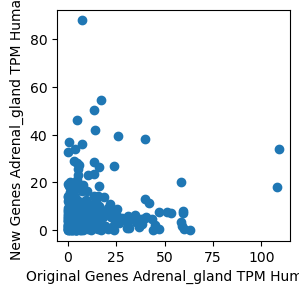

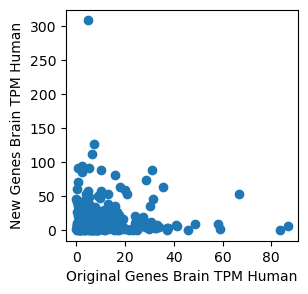

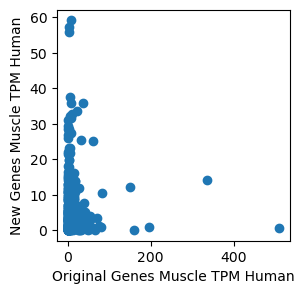

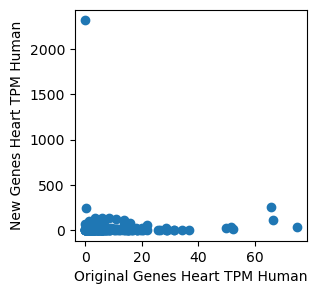

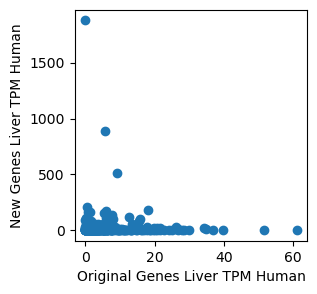

In [ ]:
# Delete the genes of original that are not in new_original
original_genes = pd.merge(original_genes,new_genes_original[["gene_name", "gene_id_human", "gene_id_mouse"]],on=["gene_name", "gene_id_human", "gene_id_mouse"],how="inner")    

# Correlation between expressions in original_genes and new_genes for each tissue
import matplotlib.pyplot as plt
for tissue in ["adrenal_gland", "brain", "muscle", "heart", "liver"]:
    x = original_genes[f"{tissue}_tpm_human"]
    y = new_genes_original[f"{tissue}_tpm_human"]

    # New figure
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel(f"Original Genes {tissue.capitalize()} TPM Human")
    plt.ylabel(f"New Genes {tissue.capitalize()} TPM Human")

In [35]:
# Filter out outliers (expression > 150) in mouse new genes in any tissue
for tissue in ["adrenal_gland", "brain", "muscle", "heart", "liver"]:
    new_genes_original = new_genes_original[new_genes_original[f"{tissue}_tpm_mouse"] <= 150]
    new_genes_original = new_genes_original[new_genes_original[f"{tissue}_tpm_human"] <= 150]

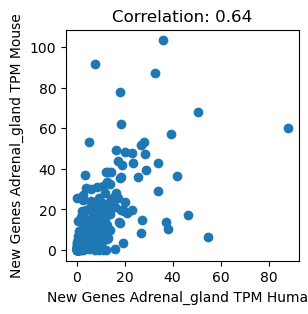

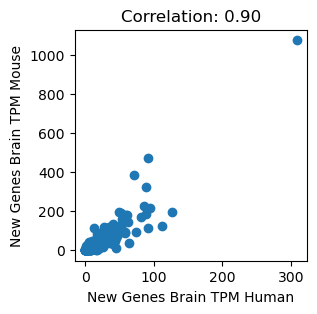

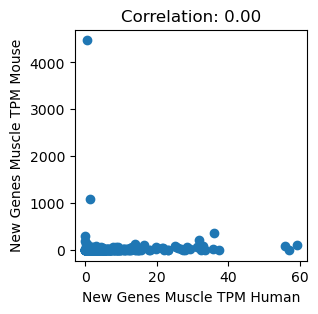

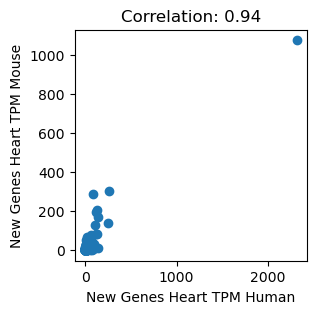

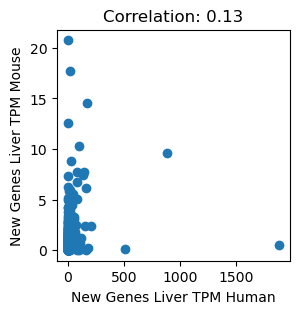

In [39]:
import matplotlib.pyplot as plt
for tissue in ["adrenal_gland", "brain", "muscle", "heart", "liver"]:
    x = new_genes_original[f"{tissue}_tpm_human"]
    y = new_genes_original[f"{tissue}_tpm_mouse"]

    # New figure
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel(f"New Genes {tissue.capitalize()} TPM Human")
    plt.ylabel(f"New Genes {tissue.capitalize()} TPM Mouse")

    correlation = x.corr(y)
    plt.title(f"Correlation: {correlation:.2f}")

# PROMOTERS

In [44]:
import requests
import json
import time
import pandas as pd

In [46]:

def get_promoter_sequences_batch(gene_list, upstream=500):
    """
    Fetches promoter sequences in batches of 50 using POST requests.
    """
    url = "https://rest.ensembl.org/sequence/id"
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json"
    }
    
    results = {}
    
    # Ensembl POST limit is 50 IDs per request
    for i in range(0, len(gene_list), 50):
        print(f"Processing batch {i//50 + 1}")
        batch = list(gene_list[i:i+50])
        data = {
            "ids": batch,
            "type": "genomic",
            "expand_5prime": upstream
        }
        
        # Convert dictionary to JSON string for the POST body
        response = requests.post(url, headers=headers, data=json.dumps(data))
        
        if response.ok:
            batch_results = response.json()
            for entry in batch_results:
                # The prompt asks for ONLY the first 500bp (the expanded region)
                full_seq = entry['seq']
                # Ensembl returns expanded_upstream + gene_sequence. 
                # We slice the first 'upstream' characters to get just the promoter.
                results[entry['id']] = full_seq[:upstream]
        else:
            print(f"Error fetching batch starting at {i}: {response.status_code}")
            # Wait a second if we hit a rate limit
            if response.status_code == 429:
                time.sleep(1)
        
    return results

In [47]:
# --- Execution ---
family = "kinases"

expression_data = pd.read_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/new_expression_data.txt", sep="\t")
human_ids = expression_data["gene_id_human"].tolist()
mouse_ids = expression_data["gene_id_mouse"].tolist()

# Retrieve in batches
promoters_human = get_promoter_sequences_batch(human_ids)
promoters_mouse = get_promoter_sequences_batch(mouse_ids)

# --- Save to FASTA ---
def save_fasta(data_dict, filename):
    with open(filename, "w") as f:
        for gene, seq in data_dict.items():
            if seq: # Ensure sequence exists
                f.write(f">{gene}\n{seq}\n")

human_file = f"C:/Users/vicfo/Desktop/TFM/Data/Datasets/sequences/human/promoter_{family}_human_new.fasta"
mouse_file = f"C:/Users/vicfo/Desktop/TFM/Data/Datasets/sequences/mouse/promoter_{family}_mouse_new.fasta"

save_fasta(promoters_human, human_file)
save_fasta(promoters_mouse, mouse_file)

print("Done! Batch retrieval completed.")

Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Done! Batch retrieval completed.


## CHECKING THE STATEMENET of "Expression values are usually log-transformed because they are log-normally distributee). 

In [12]:
# Access to the gene expression file
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/vicfo/Desktop/TFM/project/data/data_gathering/new/new_expression_data.txt", sep="\t")

# Log transform all the expression values
df_log = df.copy()
for tissue in ["adrenal_gland", "brain", "muscle", "heart", "liver"]:
    for specie in ["human", "mouse"]:
        df_log[f"{tissue}_tpm_{specie}"] = df_log[f"{tissue}_tpm_{specie}"].apply(lambda x: 0 if x == 0 else np.log2(x))
df_log

,gene_id_human,gene_id_mouse,gene_name,adrenal_gland_tpm_human,brain_tpm_human,muscle_tpm_human,heart_tpm_human,liver_tpm_human,adrenal_gland_tpm_mouse,brain_tpm_mouse,muscle_tpm_mouse,heart_tpm_mouse,liver_tpm_mouse
0,ENSG00000004660,ENSMUSG00000020785,CAMKK1,1.157044,4.846995,-2.836501,0.367371,-2.473931,0.485427,5.616181,-3.184425,-1.434403,-5.058894
1,ENSG00000006062,ENSMUSG00000020941,MAP3K14,0.839960,0.963474,1.454176,2.480265,4.539779,1.709291,0.526069,0.855990,-0.014500,-2.736966
2,ENSG00000006432,ENSMUSG00000042724,MAP3K9,-0.395929,3.666757,0.310340,0.163499,1.063503,-0.200913,4.721373,-3.473931,-5.643856,-6.643856
3,ENSG00000006837,ENSMUSG00000020389,CDKL3,-0.577767,1.937344,-1.120294,1.608809,-2.943416,1.137504,3.025029,0.111031,1.042644,-2.473931
4,ENSG00000007047,ENSMUSG00000030397,MARK4,2.010780,4.650190,2.797013,4.415488,4.130107,3.490570,5.016585,3.049631,3.102658,-2.395929
...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,ENSG00000211455,ENSMUSG00000001630,STK38L,2.541019,3.547203,1.618239,6.013686,2.521051,2.666757,3.427606,2.163499,2.462052,0.176323
294,ENSG00000213923,ENSMUSG00000022433,CSNK1E,3.834913,5.530445,3.544733,5.233044,4.152183,4.655352,6.216843,4.484138,4.158660,-1.089267
295,ENSG00000231274,ENSMUSG00000085272,SBK3,0.000000,0.000000,-5.643856,0.389567,1.594549,-3.836501,-0.971431,-1.152003,3.972693,0.000000
296,ENSG00000263528,ENSMUSG00000042349,IKBKE,0.443607,-0.577767,-1.000000,-1.358454,-3.184425,2.330558,-0.785875,-2.556393,-0.761213,0.757023


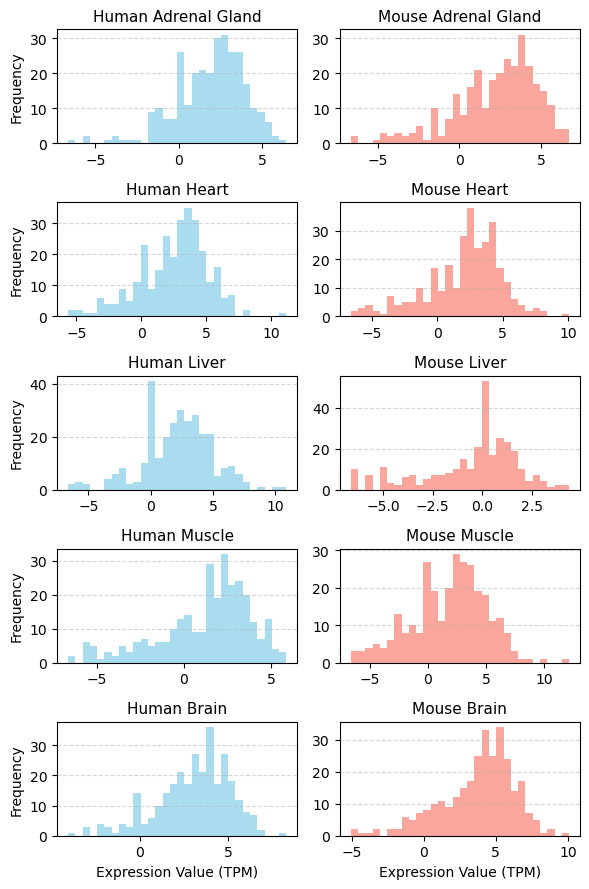

In [13]:
import matplotlib.pyplot as plt
df=df_log
tissues = ["adrenal_gland", "heart", "liver", "muscle", "brain"]

# Create a 5x2 grid of subplots (rows=tissues, columns=species)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(6, 9), sharex=False)

for i, tissue in enumerate(tissues):
    # --- Human Plot (Column 0) ---
    ax_human = axes[i, 0]
    ax_human.hist(df[f"{tissue}_tpm_human"], bins=30, color="skyblue", alpha=0.7)
    ax_human.set_ylabel("Frequency", fontsize=10)
    ax_human.set_title(f"Human {tissue.replace('_', ' ').title()}", fontsize=11)
    ax_human.grid(axis="y", linestyle="--", alpha=0.5)

    # --- Mouse Plot (Column 1) ---
    ax_mouse = axes[i, 1]
    ax_mouse.hist(df[f"{tissue}_tpm_mouse"], bins=30, color="salmon", alpha=0.7)
    ax_mouse.set_title(f"Mouse {tissue.replace('_', ' ').title()}", fontsize=11)
    ax_mouse.grid(axis="y", linestyle="--", alpha=0.5)

    # Add X-axis labels only to the bottom-most subplots
    if i == len(tissues) - 1:
        ax_human.set_xlabel("Expression Value (TPM)", fontsize=10)
        ax_mouse.set_xlabel("Expression Value (TPM)", fontsize=10)

# Clean up layout pacing and prevent overlapping text
plt.tight_layout()
plt.show()
